# Week 2 · Exercise: metrics, imbalance and overfitting

**Goal:** catch credit-card fraud when only **0.17%** of transactions are fraud, and know how good
the model really is.

Data: the ULB credit-card fraud set. 284,807 transactions over two days, **492 frauds**.
`V1`-`V28` are anonymized (a PCA of the original transaction details), `Time` is seconds since the
first transaction, `Amount` is the purchase amount, `Class` is 1 for fraud.

**Setup (once):** the data is not in git (150 MB). Follow *Reproducing this* at the bottom of
`notes/week-02.md` to create `data/raw/creditcard.csv`. Don't use `fetch_openml` for it: it
silently drops the `Time` column.

**Protocol for the whole notebook** (this is Week 1's lesson applied):
- Fit on `train`. Choose models, settings and thresholds on `val`.
- The `test` split is created in the next cell and **not touched** here. It is scored once, by the
  scripts in `classical_ml/reports/`.
- Explore on `train` only. Looking at every row before choosing features is a small leak.

The finished code lives in `classical_ml/reports/week2_metrics.py` (single-split table) and
`week2_cv.py` (5-fold comparison). This notebook is the scratchpad where you see *why* each choice
was made. Look for **✏️ Try it** cells. Running everything takes a few minutes; the gradient
boosting cells are the slowest.

## 1. Look before you model

In [5]:
import numpy as np
import pandas as pd
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)

from classical_ml.data import train_val_test_split

df = pd.read_csv("../../data/raw/creditcard.csv")
train, val, test = train_val_test_split(df, target="Class")   # stratified, 70/15/15
Xtr, ytr = train.drop(columns="Class"), train["Class"]
Xv, yv = val.drop(columns="Class"), val["Class"]

print(f"{len(df):,} transactions, {df['Class'].sum()} frauds ({df['Class'].mean():.3%})")
pd.DataFrame(
    {"rows": [len(train), len(val), len(test)],
     "frauds": [ytr.sum(), yv.sum(), test["Class"].sum()]},
    index=["train", "val", "test"],
)

284,807 transactions, 492 frauds (0.173%)


,rows,frauds
train,199364,344
val,42721,74
test,42722,74


### Plot style

Charts here use one quiet style: thin 2px lines, a recessive hairline grid, no top or right border,
text in neutral ink (never the series colour) and a fixed colour order. A model keeps the **same
colour in every chart**: logistic regression blue, gradient boosting orange, class weights green
(dashed), SMOTE yellow (dotted). The line style is a second cue for anyone who can't tell the
colours apart. Plots need `matplotlib` (in the `notebooks` group, so `uv sync --all-groups`).

In [7]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, roc_curve

INK, INK2, GRID, SURFACE, GRAY = "#0b0b0b", "#52514e", "#e6e5e1", "#fcfcfb", "#8a8985"
BLUE, ORANGE, AQUA, YELLOW = "#2a78d6", "#eb6834", "#1baf7a", "#eda100"   # categorical slots 1-4

plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "axes.edgecolor": GRID, "axes.labelcolor": INK2, "axes.titlecolor": INK,
    "axes.titlesize": 12, "axes.titleweight": "semibold", "axes.titlelocation": "left",
    "xtick.color": INK2, "ytick.color": INK2, "text.color": INK, "font.size": 10,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 1, "grid.linestyle": "-",
    "axes.axisbelow": True, "lines.linewidth": 2, "legend.frameon": False,
    "legend.labelcolor": INK2, "figure.dpi": 110,
})

def dot(ax, x, y, label=None, color=INK, dx=8, dy=8, ha="left"):
    # A marker with a surface-coloured ring, so it stays readable on top of a line.
    ax.plot([x], [y], "o", color=color, markersize=9, markeredgecolor=SURFACE,
            markeredgewidth=2, zorder=5)
    if label:
        ax.annotate(label, (x, y), xytext=(dx, dy), textcoords="offset points",
                    color=INK2, fontsize=9, ha=ha)

Only **about 74 frauds** sit in each of validation and test. Keep that number in mind all week:
any score computed on 74 positives wobbles, and later you'll see it flip the ranking of two models.

From here on, exploration uses `train` only.

In [8]:
train[["Time", "Amount"]].describe().round(1)

,Time,Amount
count,199364.0,199364.0
mean,94898.2,88.4
std,47489.9,253.1
min,0.0,0.0
25%,54253.8,5.7
50%,84845.5,22.0
75%,139365.0,77.5
max,172792.0,25691.2


In [9]:
train.groupby("Class")["Amount"].agg(["median", "mean", "max"]).round(1)

,median,mean,max
Class,,,
0,22.0,88.3,25691.2
1,7.6,118.7,2125.9


Fraud is not the big, dramatic transaction you might imagine: the median fraud amount is *smaller*
than the median normal one.

**✏️ Try it:** using `train` only, compute (a) the fraud rate by hour of day,
`(train["Time"] / 3600) % 24` rounded down, and (b) what share of all frauds have `Amount <= 1`.
Which hours look unusual? (There's no clock hour 0 in this data: it counts from the first
transaction, so only the *shape* of the pattern means anything.)

In [10]:
# your code here

## 2. Why accuracy lies

A "model" that labels **every** transaction *not fraud* needs no learning at all.

In [11]:
from sklearn.dummy import DummyClassifier

dummy = DummyClassifier(strategy="most_frequent").fit(Xtr, ytr)
pred = dummy.predict(Xv)
print(f"accuracy {accuracy_score(yv, pred):.4f}")
print(f"frauds caught: {int(((pred == 1) & (yv == 1)).sum())} of {int(yv.sum())}")

accuracy 0.9983
frauds caught: 0 of 74


**99.83% accurate, zero fraud caught.** When one class is 99.8% of the data, accuracy only measures
how common that class is. We need metrics that look at the rare class directly.

**✏️ Try it:** the opposite do-nothing model flags *everything* as fraud. What are its recall and
its precision? (Precision here equals a number you already know from section 1.)

In [12]:
# your code here

## 3. Precision, recall and F1: sort the model's calls into four boxes

|  | actually fraud | actually fine |
|---|---|---|
| **model flagged** | TP (caught) | FP (false alarm) |
| **model didn't flag** | FN (missed) | TN |

- **Precision** = TP / (TP + FP): of what I *flagged*, how much was real?  Punishes false alarms.
- **Recall** = TP / (TP + FN): of the *real frauds*, how many did I catch?  Punishes misses.
- **F1** = their harmonic mean: high only when *both* are high.

A toy example: 1,000 transactions, 10 fraud. The model flags 20 and 8 of those are fraud.

In [13]:
tp, fp, fn, tn = 8, 12, 2, 978
precision = tp / (tp + fp)
recall = tp / (tp + fn)
print(f"precision {precision:.2f}   recall {recall:.2f}   F1 {2 * precision * recall / (precision + recall):.2f}")

precision 0.40   recall 0.80   F1 0.53


**✏️ Try it:** a model flags 600 transactions, and 400 of those are real fraud. The dataset has 492
frauds in total. What are its precision and recall? (Watch the rounding: 0.8130 is 0.81, not 0.82.)

In [14]:
# your code here

Now a real model: logistic regression with a scaler (the same kind of pipeline as Week 1).

In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

base = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000)).fit(Xtr, ytr)
p_base = base.predict_proba(Xv)[:, 1]          # P(fraud) for each validation transaction

tn, fp, fn, tp = confusion_matrix(yv, p_base >= 0.5).ravel()
pd.DataFrame([[tp, fp], [fn, tn]], index=["flagged", "not flagged"],
             columns=["actually fraud", "actually fine"])

,actually fraud,actually fine
flagged,44,12
not flagged,30,42635


## 4. The threshold is a dial

A model outputs a **probability**. *You* choose the cutoff above which you flag. Move it and you
slide along a trade-off:

- **Lower** threshold: more flagged, so more fraud caught (**recall up**) and more false alarms
  (**precision down**).
- **Higher** threshold: the opposite.

There is no single "right" setting. It depends on what each kind of mistake costs (section 8).

In [16]:
def at_threshold(y, p, t):
    flagged = p >= t
    return {
        "threshold": t,
        "flagged": int(flagged.sum()),
        "precision": precision_score(y, flagged, zero_division=0),
        "recall": recall_score(y, flagged),
    }

pd.DataFrame([at_threshold(yv, p_base, t) for t in (0.9, 0.5, 0.1, 0.02)]).round(3)

,threshold,flagged,precision,recall
0,0.90,47,0.766,0.486
1,0.50,56,0.786,0.595
2,0.10,75,0.707,0.716
3,0.02,113,0.531,0.811


**See the dial.** Every threshold gives one (precision, recall) pair; plot them all. The jagged
precision line on the right is the 74-frauds noise showing up as a picture.

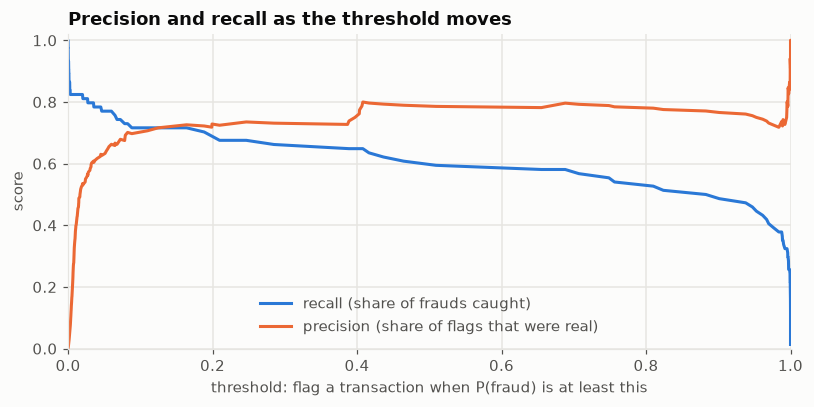

In [21]:
prec, rec, thr = precision_recall_curve(yv, p_base)

fig, ax = plt.subplots(figsize=(7.5, 3.8))
ax.plot(thr, rec[:-1], color=BLUE, label="recall (share of frauds caught)")
ax.plot(thr, prec[:-1], color=ORANGE, label="precision (share of flags that were real)")
ax.set(xlim=(0, 1), ylim=(0, 1.02), ylabel="score",
       xlabel="threshold: flag a transaction when P(fraud) is at least this")
ax.set_title("Precision and recall as the threshold moves")
ax.legend(loc="lower center")
fig.tight_layout()
plt.show()

Recall rises steadily as the threshold falls. Precision falls *overall*, but look closely at the top
two rows: it can tick up slightly. With 74 frauds, one transaction more or less moves it. Don't read
small wiggles as patterns.

**✏️ Try it:** find the highest threshold at which recall is still at least 0.9, and the precision
you get there. (Hint: loop over a grid such as `np.linspace(0.001, 0.5, 200)` with `at_threshold`.)

In [18]:
# your code here

## 5. ROC-AUC vs PR-AUC

Both summarize the model over *every* threshold, but they divide by different things:

| | x-axis / question | divides false alarms by |
|---|---|---|
| **ROC** | false-positive rate | **all legitimate** transactions (about 42,650 here) |
| **PR** | precision | **only the transactions flagged** |

When legitimate transactions outnumber fraud 600 to 1, even a pile of false alarms is a tiny share
of them, so ROC looks great while a human reviewer sees mostly wrong flags.

In [19]:
legit = int((yv == 0).sum())
flagged = p_base >= 0.02
fp = int((flagged & (yv == 0)).sum())
tp = int((flagged & (yv == 1)).sum())

print(f"threshold 0.02 flags {flagged.sum()}: {tp} real, {fp} false alarms")
print(f"false-positive rate = {fp}/{legit:,} = {fp / legit:.3%}   <- what ROC sees")
print(f"precision           = {tp}/{flagged.sum()} = {tp / flagged.sum():.1%}   <- what a reviewer sees")
print(f"double the legit volume: FPR becomes {fp / (2 * legit):.3%}, precision stays {tp / flagged.sum():.1%}")
print()
print(f"ROC-AUC {roc_auc_score(yv, p_base):.3f}   (chance 0.500)")
print(f"PR-AUC  {average_precision_score(yv, p_base):.3f}   (chance {yv.mean():.4f}, the fraud rate)")

threshold 0.02 flags 113: 60 real, 53 false alarms
false-positive rate = 53/42,647 = 0.124%   <- what ROC sees
precision           = 60/113 = 53.1%   <- what a reviewer sees
double the legit volume: FPR becomes 0.062%, precision stays 53.1%

ROC-AUC 0.957   (chance 0.500)
PR-AUC  0.670   (chance 0.0017, the fraud rate)


**See it.** The same model and the same predictions, drawn two ways. The dots mark two thresholds
you've already met (0.5 and 0.02).

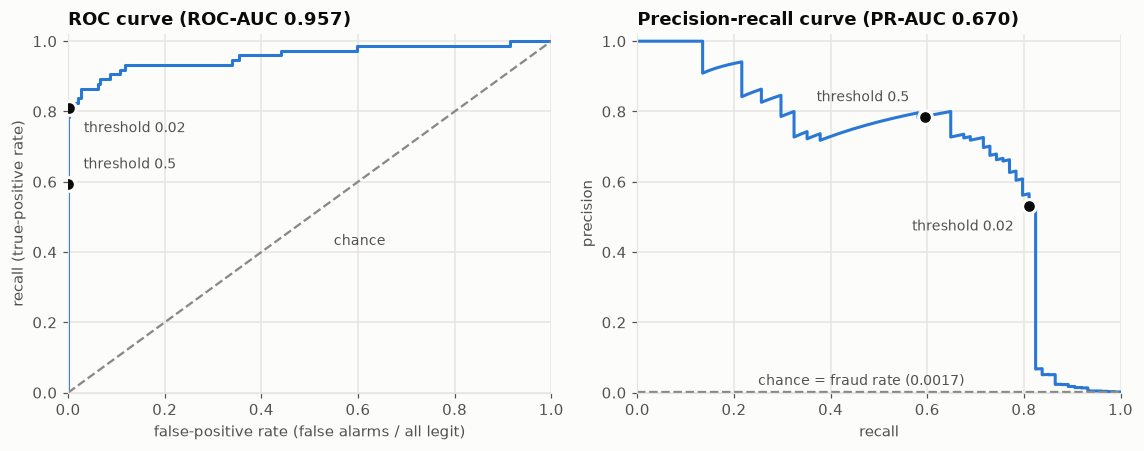

In [20]:
fpr, tpr, _ = roc_curve(yv, p_base)
prec, rec, _ = precision_recall_curve(yv, p_base)

def operating_point(t):
    flagged = p_base >= t
    tp = int((flagged & (yv == 1)).sum())
    fp = int((flagged & (yv == 0)).sum())
    return fp / int((yv == 0).sum()), tp / int(yv.sum()), tp / max(int(flagged.sum()), 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10.5, 4.2))

ax1.plot(fpr, tpr, color=BLUE)
ax1.plot([0, 1], [0, 1], color=GRAY, linestyle="--", linewidth=1.5)
ax1.text(0.55, 0.42, "chance", color=INK2, fontsize=9)
ax1.set(xlim=(0, 1), ylim=(0, 1.02), xlabel="false-positive rate (false alarms / all legit)",
        ylabel="recall (true-positive rate)")
ax1.set_title(f"ROC curve (ROC-AUC {roc_auc_score(yv, p_base):.3f})")

ax2.plot(rec, prec, color=BLUE)
ax2.axhline(yv.mean(), color=GRAY, linestyle="--", linewidth=1.5)
ax2.text(0.25, yv.mean() + 0.02, f"chance = fraud rate ({yv.mean():.4f})", color=INK2, fontsize=9)
ax2.set(xlim=(0, 1), ylim=(0, 1.02), xlabel="recall", ylabel="precision")
ax2.set_title(f"Precision-recall curve (PR-AUC {average_precision_score(yv, p_base):.3f})")

for t, (dx, dy) in {0.5: (10, 10), 0.02: (10, -16)}.items():
    f, r, p = operating_point(t)
    dot(ax1, f, r, f"threshold {t}", dx=dx, dy=dy)
    dot(ax2, r, p, f"threshold {t}", dx=-10, dy=dy, ha="right")

fig.tight_layout()
plt.show()

Look at threshold 0.02 on both charts. On the ROC curve it sits almost in the top-left corner
(false-positive rate about 0.1%, recall 0.81): it looks superb, and the whole curve hugs the left
edge because the false-positive rate is divided by 42,000+ legitimate transactions. On the
precision-recall curve the *same point* is at precision 0.53, with the curve far from the top-right
corner. The PR chart shows the problem; the ROC chart hides it.

**Chance is different for each.** ROC-AUC's chance level is 0.5. PR-AUC's chance level is the
**fraud rate** (0.0017), so a PR-AUC of 0.67 is roughly 390 times better than guessing even though
it "sounds" mediocre. Always check what chance scores before judging a number.

**✏️ Try it:** give every validation transaction the same score (`np.zeros(len(yv))`) and compute
`average_precision_score`. What do you get, and why?

In [ ]:
# your code here

## 6. Imbalance fix 1: class weights

`class_weight="balanced"` makes each fraud count roughly as much as 580 normal transactions in the
training loss (284,315 / 492 ≈ 578): "don't ignore the rare class." Compare with and without.

In [23]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score, precision_score, recall_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

probs = {}
for name, weights in [("no weights", None), ("balanced", "balanced")]:
    model = make_pipeline(
        StandardScaler(), LogisticRegression(max_iter=1000, class_weight=weights)
    ).fit(Xtr, ytr)
    p = model.predict_proba(Xv)[:, 1]
    probs[name] = p
    pred = p >= 0.5
    print(f"{name:10} PR-AUC {average_precision_score(yv, p):.3f} | ROC-AUC {roc_auc_score(yv, p):.3f}"
          f" | flagged {pred.sum():5d}, precision {precision_score(yv, pred, zero_division=0):.3f},"
          f" recall {recall_score(yv, pred):.3f}")

no weights PR-AUC 0.670 | ROC-AUC 0.957 | flagged    56, precision 0.786, recall 0.595
balanced   PR-AUC 0.630 | ROC-AUC 0.968 | flagged   969, precision 0.067, recall 0.878


Balanced weights flag ~17 times as many transactions at 0.5, with recall up and precision collapsed,
and PR-AUC did **not** improve. Is it a better model, or just a lower effective threshold? Test it:
flag the same *number* of transactions with each and compare.

In [24]:
def top_k(y, p, k):
    return at_threshold(y, p, np.sort(p)[::-1][k - 1])

k = int((probs["balanced"] >= 0.5).sum())
print("mean predicted P(fraud):",
      {n: round(float(p.mean()), 4) for n, p in probs.items()}, "| true rate:", round(float(yv.mean()), 4))
pd.DataFrame({n: top_k(yv, p, k) for n, p in probs.items()}).T.round(3)

mean predicted P(fraud): {'no weights': 0.0018, 'balanced': 0.0657} | true rate: 0.0017


,threshold,flagged,precision,recall
no weights,0.003,969.0,0.064,0.838
balanced,0.501,969.0,0.067,0.878


At the same number of flags the two models are nearly identical. The weighted model's *average*
predicted probability is ~40 times too high (0.066 vs the true 0.0017): the weights **inflate the
probabilities**, so more cross 0.5, but they barely change how well the model *ranks* transactions.
Class weights mostly move you along the same precision-recall curve.

## 7. Imbalance fix 2: SMOTE

**SMOTE** invents *synthetic* frauds: take a real fraud, find a nearby real fraud, and create a new
point somewhere on the line between them. The training set then looks less lopsided.

The leakage rule from Week 1 applies with full force. A synthetic fraud is built from real ones, so
if you run SMOTE **before** splitting, a synthetic training point can sit right next to a validation
fraud, and the score is inflated. SMOTE must run **inside the pipeline, on training rows only**, and
never on validation or test, which must keep the real fraud rate. Use `imblearn`'s `Pipeline`
(scikit-learn's can't hold a resampling step).

In [25]:
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

smote = ImbPipeline([
    ("scale", StandardScaler()),
    ("smote", SMOTE(random_state=0)),
    ("model", LogisticRegression(max_iter=1000)),
]).fit(Xtr, ytr)
p_smote = smote.predict_proba(Xv)[:, 1]
probs["smote"] = p_smote

pred = p_smote >= 0.5
print(f"smote      PR-AUC {average_precision_score(yv, p_smote):.3f} | ROC-AUC {roc_auc_score(yv, p_smote):.3f}"
      f" | flagged {pred.sum():5d}, precision {precision_score(yv, pred, zero_division=0):.3f},"
      f" recall {recall_score(yv, pred):.3f}")

smote      PR-AUC 0.634 | ROC-AUC 0.967 | flagged   998, precision 0.065, recall 0.878


SMOTE lands almost exactly where class weights did: it also teaches the model that fraud is as
common as normal transactions, so it also inflates probabilities. For this problem it added a
dependency, longer training and a leakage risk, and bought nothing.

**✏️ Try it (break it on purpose):** apply `SMOTE().fit_resample` to the *whole* `train + val` data
first, then split the result and score on the "validation" part. Does the score look better? Why is
that number meaningless?

In [26]:
# your code here

## 8. Imbalance fix 3: tune the threshold (and ask what a miss costs)

The third fix needs **no retraining**: keep the model and choose the cutoff deliberately, on
**validation** (never train: the model has seen it; never test: you touch it once).

Two common rules:
- **Best F1**: the threshold where F1 peaks. Convenient, but F1 treats a miss and a false alarm as
  equally bad.
- **Minimum cost**: put a price on each mistake and minimize the total. Say a missed fraud costs
  $500 and a false alarm costs $5 of reviewer time.

For a well-calibrated model the break-even rule is *flag when P(fraud) x miss cost > review cost*:
P > 5 / (500 + 5) ≈ **1%**. If a miss cost only $20, the break-even would be 5 / 25 = **20%**.

In [27]:
COST_MISS, COST_ALARM = 500, 5

def total_cost(y, p, t):
    flagged = p >= t
    missed = int(((~flagged) & (y == 1)).sum())
    false_alarms = int((flagged & (y == 0)).sum())
    return COST_MISS * missed + COST_ALARM * false_alarms

def best_cost_threshold(y, p):
    # Sort once, then cost of flagging the top-k is cheap to compute for every k at once.
    order = np.argsort(-p)
    hits = y.to_numpy()[order]
    caught, alarms = np.cumsum(hits), np.cumsum(1 - hits)
    cost = COST_MISS * (hits.sum() - caught) + COST_ALARM * alarms
    best = int(np.argmin(cost))
    return float(p[order][best])

from sklearn.metrics import precision_recall_curve

prec, rec, thr = precision_recall_curve(yv, p_base)
f1 = 2 * prec[:-1] * rec[:-1] / np.maximum(prec[:-1] + rec[:-1], 1e-12)

rules = {"default 0.5": 0.5, "best F1": float(thr[f1.argmax()]),
         "min cost": best_cost_threshold(yv, p_base)}
pd.DataFrame(
    {name: {**at_threshold(yv, p_base, t), "F1": f1_score(yv, p_base >= t),
            "cost ($)": total_cost(yv, p_base, t)} for name, t in rules.items()}
).T.round(3)

,threshold,flagged,precision,recall,F1,cost ($)
default 0.5,0.500,56.0,0.786,0.595,0.677,15060.0
best F1,0.164,73.0,0.726,0.716,0.721,10600.0
min cost,0.020,114.0,0.535,0.824,0.649,6765.0


**See the cost.** Total cost at every threshold (log scale on the x axis, because the useful
thresholds are small). The dashed line is what *flagging nothing* costs (74 missed frauds x $500).

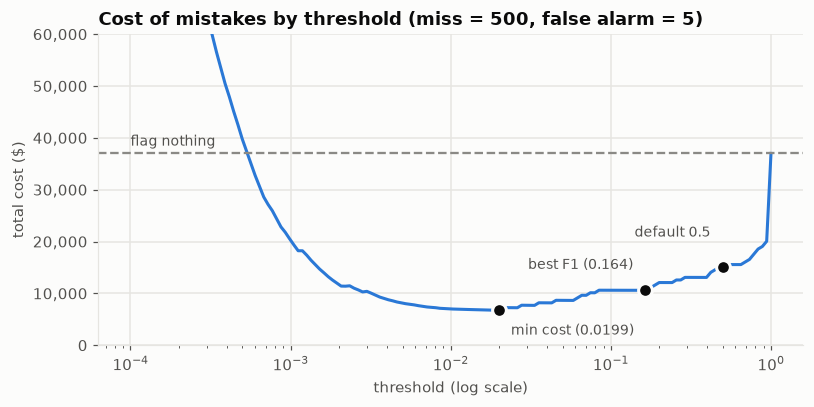

In [29]:
grid_t = np.logspace(-4, 0, 150)
costs = [total_cost(yv, p_base, t) for t in grid_t]

fig, ax = plt.subplots(figsize=(7.5, 3.8))
ax.plot(grid_t, costs, color=BLUE)
ax.axhline(COST_MISS * int(yv.sum()), color=GRAY, linestyle="--", linewidth=1.5)
ax.text(1e-4, COST_MISS * int(yv.sum()) + 1500, "flag nothing", color=INK2, fontsize=9)
offsets = [(-8, 20, "right"), (-8, 14, "right"), (8, -16, "left")]
for (name, t), (dx, dy, ha) in zip(rules.items(), offsets):
    label = name if "0.5" in name else f"{name} ({t:.3g})"
    dot(ax, t, total_cost(yv, p_base, t), label, dx=dx, dy=dy, ha=ha)
ax.set(xscale="log", ylim=(0, 60000), xlabel="threshold (log scale)", ylabel="total cost ($)")
ax.set_title("Cost of mistakes by threshold (miss = 500, false alarm = 5)")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:,.0f}"))
fig.tight_layout()
plt.show()

The cheapest rule has the *worst* F1 of the three: with a miss costing 100 times a false alarm,
flagging more is worth it. **F1 is a convenient score, not a business goal.** The business goal is
whatever the real costs say.

Two honest cautions. The thresholds were chosen *on* the validation set, so these numbers are a
little optimistic (that's why the final choice is checked once on the untouched test set). And with
74 frauds, the gap between 0.164 and 0.02 isn't precise.

**✏️ Try it:** change `COST_MISS` to 20 and rerun the cell. Where does the "min cost" threshold move,
and does it match the 20% break-even from the text?

In [30]:
# your code here

## 9. Regularization: L1 and L2

A logistic regression learns one weight per feature. **Regularization** adds a price tag on the
weights, so the model must justify every large one. `C` is the *inverse* of the penalty: small `C`
means a steep price.

| | price charged | effect on a weak feature |
|---|---|---|
| **L2** | the *square* of each weight, w² | shrinks all weights; a weak feature keeps a small weight |
| **L1** | the *absolute value*, \|w\| | pushes weak features' weights **exactly to zero** (a feature selector) |

Why the difference: a weight of 0.1 costs only 0.01 under L2 (not worth removing) but 0.10 under L1
(removed unless it earns it back).

In [33]:
rows = []
for penalty, l1_ratio in (("l2", 0.0), ("l1", 1.0)):     # l1_ratio: 0 = pure L2, 1 = pure L1
    for C in (0.001, 0.01, 0.1, 1, 10):
        m = make_pipeline(
            StandardScaler(),
            LogisticRegression(l1_ratio=l1_ratio, C=C, solver="liblinear", max_iter=2000),
        ).fit(Xtr, ytr)
        rows.append({
            "penalty": penalty, "C": C,
            "PR-AUC (train)": average_precision_score(ytr, m.predict_proba(Xtr)[:, 1]),
            "PR-AUC (val)": average_precision_score(yv, m.predict_proba(Xv)[:, 1]),
            "non-zero weights": int((np.abs(m[-1].coef_[0]) > 1e-9).sum()),
        })
pd.DataFrame(rows).round(3)

,penalty,C,PR-AUC (train),PR-AUC (val),non-zero weights
0,l2,0.001,0.778,0.643,30
1,l2,0.010,0.785,0.659,30
2,l2,0.100,0.791,0.669,30
3,l2,1.000,0.792,0.673,30
4,l2,10.000,0.792,0.674,30
5,l1,0.001,0.717,0.605,3
6,l1,0.010,0.757,0.640,7
7,l1,0.100,0.789,0.668,18
8,l1,1.000,0.792,0.673,30
9,l1,10.000,0.792,0.674,30


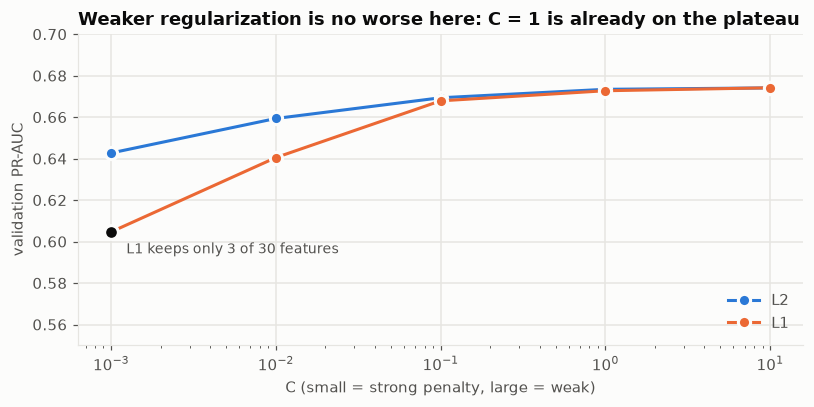

In [34]:
reg = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(7.5, 3.8))
for penalty, color, label in (("l2", BLUE, "L2"), ("l1", ORANGE, "L1")):
    d = reg[reg["penalty"] == penalty]
    ax.plot(d["C"], d["PR-AUC (val)"], color=color, label=label, marker="o", markersize=8,
            markeredgecolor=SURFACE, markeredgewidth=2)
first_l1 = reg[(reg["penalty"] == "l1") & (reg["C"] == reg["C"].min())].iloc[0]
dot(ax, first_l1["C"], first_l1["PR-AUC (val)"], f"L1 keeps only {int(first_l1['non-zero weights'])} of 30 features",
    dx=10, dy=-14)
ax.set(xscale="log", ylim=(0.55, 0.70), xlabel="C (small = strong penalty, large = weak)",
       ylabel="validation PR-AUC")
ax.set_title("Weaker regularization is no worse here: C = 1 is already on the plateau")
ax.legend(loc="lower right")
fig.tight_layout()
plt.show()

What to read from it:

- **Regularization didn't help here.** Validation PR-AUC keeps rising as the penalty weakens and is flat from
  `C = 1` upward; the default is already on the plateau. A 30-feature model on 240,000 rows has
  little room to memorize noise.
- **L1 works as a selector:** at `C = 0.001` it keeps only about 3 of 30 features and still scores
  ~0.6.
- Try `C = 0.0001` with L1 and every weight goes to zero. The model then gives every transaction the
  same score, and its PR-AUC is **0.002**: the chance level from section 5, the fraud rate.

## 10. Gradient boosting, and early stopping

A **decision tree** is a flowchart of yes/no questions about the features that ends in a number.
**Gradient boosting** builds many small trees *in sequence*, each trained to fix the errors of all
the trees before it:

```
start:   every transaction gets the same score (the average fraud rate)
round 1: find the errors, fit a small tree that predicts them, add  learning_rate x tree
round 2: recompute the errors, fit another tree, add  learning_rate x tree
...
final score = start + learning_rate x (tree 1 + tree 2 + ... + tree N)
```

- A **round** is one more tree. The **learning rate** is the step size: small steps need more
  rounds but each tree has less say.
- Unlike logistic regression's straight-line rule, trees can say "*hour is 2 **and** amount is
  under $1*": interactions and non-linear shapes.

**A trap with rare classes.** On this data, default settings go haywire. A leaf holding a handful of
frauds among tens of thousands of normal rows computes a gigantic correction (a large error
divided by a tiny quantity), so scores jump to almost exactly 1.0 after just a few rounds.

In [35]:
from sklearn.ensemble import HistGradientBoostingClassifier

for name, extra in {"default settings": {}, "l2_regularization=10": {"l2_regularization": 10.0}}.items():
    gb = HistGradientBoostingClassifier(
        max_iter=5, learning_rate=0.1, early_stopping=False, random_state=0, **extra
    ).fit(Xtr, ytr)
    p = gb.predict_proba(Xv)[:, 1]
    print(f"{name:22} after 5 rounds: highest P(fraud) = {p.max():.4f}, "
          f"validation PR-AUC = {average_precision_score(yv, p):.3f}")

default settings       after 5 rounds: highest P(fraud) = 1.0000, validation PR-AUC = 0.405
l2_regularization=10   after 5 rounds: highest P(fraud) = 0.3171, validation PR-AUC = 0.656


`l2_regularization` shrinks those leaf corrections (and `min_samples_leaf` forbids tiny leaves).
Now watch training and validation scores as the rounds pile up. This cell takes a minute or two.

In [36]:
gb = HistGradientBoostingClassifier(
    max_iter=300, learning_rate=0.1, l2_regularization=10.0, min_samples_leaf=20,
    early_stopping=False, random_state=0,
).fit(Xtr, ytr)

show = {10, 25, 50, 100, 200, 300}
rows = []
for i, (s_tr, s_v) in enumerate(zip(gb.staged_decision_function(Xtr), gb.staged_decision_function(Xv)), 1):
    if i in show:
        rows.append({"round": i, "PR-AUC (train)": average_precision_score(ytr, s_tr),
                     "PR-AUC (val)": average_precision_score(yv, s_v)})
pd.DataFrame(rows).round(3)

,round,PR-AUC (train),PR-AUC (val)
0,10,0.858,0.765
1,25,0.910,0.795
2,50,0.952,0.813
3,100,0.993,0.818
4,200,1.000,0.822
5,300,1.000,0.825


**See the plateau.** The same model, scored every 10 rounds on both splits.

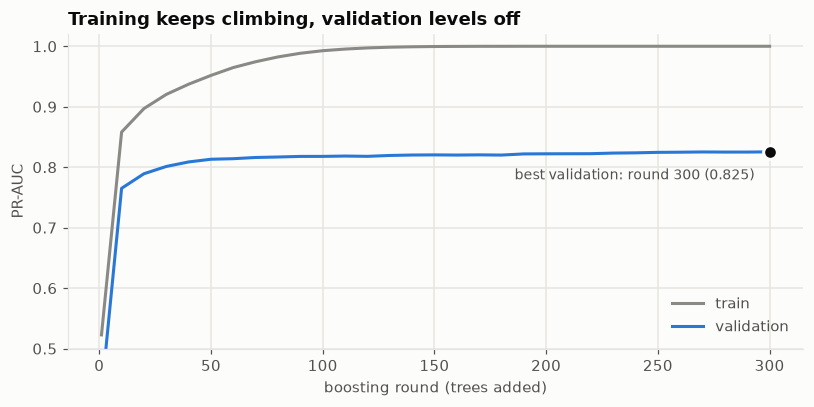

In [37]:
rounds, ap_train, ap_val = [], [], []
for i, (s_tr, s_v) in enumerate(zip(gb.staged_decision_function(Xtr), gb.staged_decision_function(Xv)), 1):
    if i == 1 or i % 10 == 0:
        rounds.append(i)
        ap_train.append(average_precision_score(ytr, s_tr))
        ap_val.append(average_precision_score(yv, s_v))

fig, ax = plt.subplots(figsize=(7.5, 3.8))
ax.plot(rounds, ap_train, color=GRAY, label="train")
ax.plot(rounds, ap_val, color=BLUE, label="validation")
best = int(np.argmax(ap_val))
dot(ax, rounds[best], ap_val[best], f"best validation: round {rounds[best]} ({ap_val[best]:.3f})",
    dx=-10, dy=-18, ha="right")
ax.set(ylim=(0.5, 1.02), xlabel="boosting round (trees added)", ylabel="PR-AUC")
ax.set_title("Training keeps climbing, validation levels off")
ax.legend(loc="lower right")
fig.tight_layout()
plt.show()

The training score climbs to a perfect 1.000 while the validation score rises fast and then flattens
near 0.82, against ~0.67 for logistic regression: boosting is clearly the stronger model here.

**Is it overfitting?** A big train-validation gap doesn't prove it: a boosted model reaches a perfect
training score almost by definition. The test is whether validation gets *worse* as capacity grows.
Here it only flattened.

**Early stopping** uses that plateau as a signal: stop adding rounds when the validation score hasn't
improved for N rounds. It saves training time, and protects you on problems where validation does
turn down. Watch out: scikit-learn's built-in version carves its validation set out of the training
data, and with ~344 training frauds that is roughly 50 frauds to judge by: a noisy signal.

**✏️ Try it:** refit with `early_stopping=True, validation_fraction=0.15, n_iter_no_change=10,
scoring="average_precision"` (keep `l2_regularization=10.0`). At which round does it stop, and what
validation PR-AUC does that give compared with the 300-round model?

In [38]:
# your code here

## 11. Feature engineering, and a negative result

Exploring `train` in section 1 suggests two engineered features:
- **Hour of day.** Fraud is about 10 times as common in the small hours (the pattern repeats over
  the two days). Raw `Time` runs to 48 hours, so use sin/cos of the hour, which wraps around.
- **Tiny amounts.** About 37% of all fraud is in transactions of $1 or less (card testing is a
  common pattern), and `Amount` is heavily skewed, so also try `log1p(Amount)`.

In [39]:
def add_features(X):
    hour = (X["Time"] / 3600) % 24
    return X.assign(
        hour_sin=np.sin(2 * np.pi * hour / 24),
        hour_cos=np.cos(2 * np.pi * hour / 24),
        is_tiny_amount=(X["Amount"] <= 1).astype(int),
        log_amount=np.log1p(X["Amount"]),
    )

Xtr_f, Xv_f = add_features(Xtr), add_features(Xv)
groups = {
    "raw columns only": [],
    "+ is_tiny_amount": ["is_tiny_amount"],
    "+ log_amount": ["log_amount"],
    "+ hour (sin, cos)": ["hour_sin", "hour_cos"],
    "+ all four": ["hour_sin", "hour_cos", "is_tiny_amount", "log_amount"],
}
new_cols = ["hour_sin", "hour_cos", "is_tiny_amount", "log_amount"]
for name, add in groups.items():
    cols = [c for c in Xtr_f.columns if c not in new_cols or c in add]
    m = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000)).fit(Xtr_f[cols], ytr)
    print(f"{name:20} validation PR-AUC {average_precision_score(yv, m.predict_proba(Xv_f[cols])[:, 1]):.3f}")

raw columns only     validation PR-AUC 0.670
+ is_tiny_amount     validation PR-AUC 0.666
+ log_amount         validation PR-AUC 0.674
+ hour (sin, cos)    validation PR-AUC 0.675
+ all four           validation PR-AUC 0.677


Nothing moves: all five scores sit within about 0.01 of each other, well inside the noise of 74
frauds. The same holds for boosting (0.822 -> 0.823 when both features were added). A **negative
result**, and worth writing down. The anonymized `V1`-`V28` already carry most of the signal.

Compare with Week 1, where `debt_to_income` helped a linear model because it *combined* two columns
the model couldn't combine itself. Feature engineering pays off when it adds information the model
can't build on its own.

## 12. Comparing models honestly

Everything above used **one validation split with 74 frauds**, and that's too little to rank models.
Two examples already seen: precision wiggled between thresholds, and on the real test split the
order of plain logistic regression versus class weights / SMOTE *flipped* relative to validation.

The fix is Week 1's: **k-fold cross-validation**, now over all 492 frauds (each is scored once, out
of fold, by a model that never trained on it), comparing models on the *same* folds. The scripts
below produce the tables (the second takes several minutes):

```bash
uv run python classical_ml/reports/week2_metrics.py   # one split, scored once on test, with intervals
uv run python classical_ml/reports/week2_cv.py        # 5-fold CV, paired comparison
```

In [40]:
from pathlib import Path

from IPython.display import Markdown, display

for name in ("week2_metrics.md", "week2_cv.md"):
    path = Path("../reports") / name
    display(Markdown(path.read_text(encoding="utf-8") if path.exists() else f"*{name} not generated yet, run the script above.*"))

Test split: 42,722 transactions, 74 frauds (0.17%).
Chance PR-AUC = fraud rate = 0.0017. Cost = $500 per missed fraud + $5 per false alarm; flagging nothing costs $37,000.

| Model | PR-AUC (95% interval) | ROC-AUC | Val threshold | Flagged | Precision | Recall | Cost ($) |
|---|---|---|---|---|---|---|---|
| Logistic regression | 0.750 [0.659-0.854] | 0.956 | 0.020 | 101 | 0.594 | 0.811 | 7,205 |
| Logistic + class weights | 0.793 [0.706-0.887] | 0.968 | 0.855 | 293 | 0.215 | 0.851 | 6,650 |
| Logistic + SMOTE | 0.794 [0.706-0.888] | 0.968 | 0.907 | 272 | 0.232 | 0.851 | 6,545 |
| Gradient boosting (regularised) | 0.842 [0.775-0.922] | 0.970 | 0.002 | 336 | 0.190 | 0.865 | 6,360 |


5-fold stratified CV over all 284,807 transactions (492 frauds, each scored once out of fold).

| Model | PR-AUC mean ± std | per-fold PR-AUC | ROC-AUC mean | vs plain logistic (mean diff ± std, folds better) |
|---|---|---|---|---|
| Logistic regression | 0.758 ± 0.021 | 0.721 0.765 0.779 0.775 0.753 | 0.974 | baseline |
| Logistic + class weights | 0.730 ± 0.025 | 0.710 0.723 0.728 0.778 0.709 | 0.979 | -0.029 ± 0.021, 1/5 |
| Logistic + SMOTE | 0.729 ± 0.029 | 0.699 0.724 0.730 0.784 0.710 | 0.978 | -0.029 ± 0.021, 1/5 |
| Gradient boosting (regularised) | 0.859 ± 0.022 | 0.848 0.895 0.871 0.849 0.830 | 0.982 | +0.100 ± 0.024, 5/5 |


**See the four models.** Same validation data, same two chart types as section 5. Watch which
chart lets you tell the models apart.

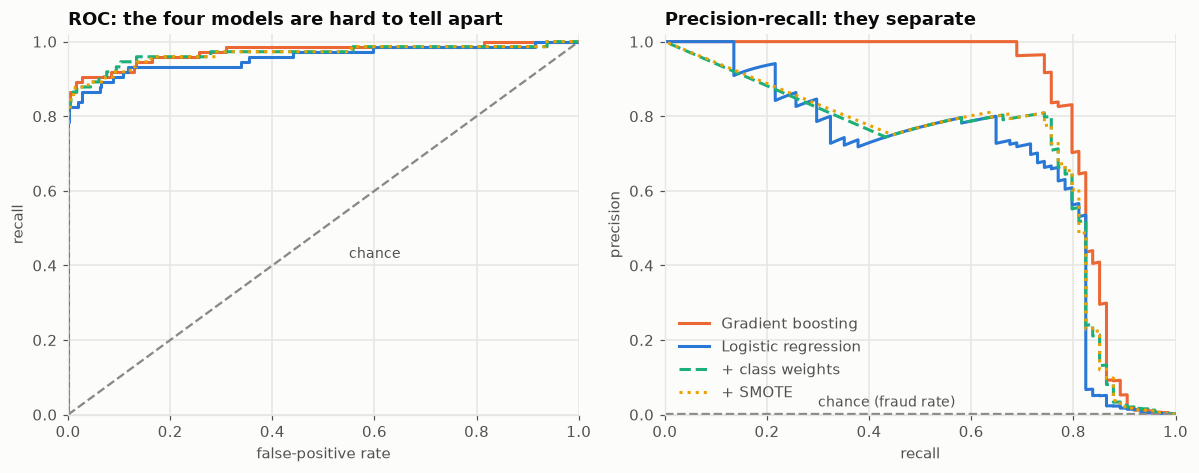

,ROC-AUC,PR-AUC
Gradient boosting,0.974,0.825
Logistic regression,0.957,0.670
+ class weights,0.968,0.630
+ SMOTE,0.967,0.634


In [41]:
MODELS = {   # name: (validation probabilities, colour, line style); the same in every chart
    "Gradient boosting": (gb.predict_proba(Xv)[:, 1], ORANGE, "-"),
    "Logistic regression": (p_base, BLUE, "-"),
    "+ class weights": (probs["balanced"], AQUA, "--"),
    "+ SMOTE": (probs["smote"], YELLOW, ":"),
}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.4))
for name, (p, color, style) in MODELS.items():
    fpr, tpr, _ = roc_curve(yv, p)
    pr, rc, _ = precision_recall_curve(yv, p)
    ax1.plot(fpr, tpr, color=color, linestyle=style, label=name)
    ax2.plot(rc, pr, color=color, linestyle=style, label=name)
ax1.plot([0, 1], [0, 1], color=GRAY, linestyle="--", linewidth=1.5)
ax2.axhline(yv.mean(), color=GRAY, linestyle="--", linewidth=1.5)
ax1.text(0.55, 0.42, "chance", color=INK2, fontsize=9)
ax2.text(0.3, yv.mean() + 0.02, "chance (fraud rate)", color=INK2, fontsize=9)
ax1.set(xlim=(0, 1), ylim=(0, 1.02), xlabel="false-positive rate", ylabel="recall")
ax1.set_title("ROC: the four models are hard to tell apart")
ax2.set(xlim=(0, 1), ylim=(0, 1.02), xlabel="recall", ylabel="precision")
ax2.set_title("Precision-recall: they separate")
ax2.legend(loc="lower left")
fig.tight_layout()
plt.show()

pd.DataFrame(
    {n: {"ROC-AUC": roc_auc_score(yv, p), "PR-AUC": average_precision_score(yv, p)}
     for n, (p, _, _) in MODELS.items()}
).T.round(3)

The table is the same information as the chart, in numbers (the green and yellow lines are the
lowest-contrast colours, so the table backs them up). Keep in mind that this is still **one
validation split with 74 frauds**. The cross-validation chart below is the one to trust for ranking.

In [ ]:
cv_path = Path("../reports/week2_cv.md")
cv_colours = {"Gradient boosting (regularised)": ORANGE, "Logistic regression": BLUE,
              "Logistic + class weights": AQUA, "Logistic + SMOTE": YELLOW}
cv_folds = {}
if cv_path.exists():
    for line in cv_path.read_text(encoding="utf-8").splitlines():
        cells = [c.strip() for c in line.strip().strip("|").split("|")]
        if len(cells) > 2 and cells[0] in cv_colours:
            cv_folds[cells[0]] = [float(v) for v in cells[2].split()]

if cv_folds:
    names = [n for n in cv_colours if n in cv_folds]          # boosting first, top row
    fig, ax = plt.subplots(figsize=(8, 3.6))
    for y_pos, name in zip(range(len(names), 0, -1), names):
        scores = cv_folds[name]
        ys = [y_pos + (k - 2) * 0.09 for k in range(len(scores))]   # stagger by fold
        ax.plot(scores, ys, "o", color=cv_colours[name], markersize=9,
                markeredgecolor=SURFACE, markeredgewidth=2, linestyle="none")
        ax.plot([np.mean(scores)] * 2, [y_pos - 0.3, y_pos + 0.3], color=INK, linewidth=2)
    ax.set_yticks(range(len(names), 0, -1), names)
    ax.set(xlabel="PR-AUC on each of the 5 folds (dots, staggered by fold); black bar = mean", ylim=(0.4, len(names) + 0.6))
    ax.grid(axis="y", visible=False)
    ax.set_title("5-fold cross-validation over all 492 frauds")
    fig.tight_layout()
    plt.show()
else:
    print("Run classical_ml/reports/week2_cv.py first to create week2_cv.md.")

Boosting's five dots all sit to the right of every other model's dots, with no overlap: it wins on
every fold. Plain logistic regression, class weights and SMOTE overlap heavily, so those three are
not clearly different. That is what "better than the noise" looks like.

How to read the two tables:

- **Single test split.** All four models cut the cost of flagging nothing by about 80%, but their
  PR-AUC intervals overlap, so it can't pick a winner.
- **5-fold CV.** Regularized gradient boosting beats plain logistic regression on **every fold**
  (about +0.10, roughly four times the fold-to-fold spread). Class weights and SMOTE give no
  benefit (they were worse on 4 of 5 folds). ROC-AUC (0.974 to 0.982) would have hidden all of it.
- **Thresholds can't be compared across models.** Weighted and SMOTE models land near 0.9, plain
  logistic regression near 0.02, and boosting near 0.002 (its heavy regularization shrinks its
  probabilities). Tune each model's threshold on its own.

## ✏️ Your turn

Do these here first, then move anything reusable into `classical_ml/reports/` or the package
**with a test**.

1. **Random vs time-based split.** Sort `df` by `Time`, train on the first 70% and score the last
   30%. Compare PR-AUC with the random split. Why can a time-based split score *worse*, and why is
   it still the honest choice for real fraud detection?
2. **Hit a recall target.** Find the highest threshold with recall >= 0.9 on validation. What is
   the precision there, and what does it cost under the $500 / $5 rule?
3. **Cost sensitivity.** Rerun section 8 for miss costs of 5, 20, 100, 500, 2000 (alarm cost 5).
   Tabulate the best threshold and the number flagged. Does the threshold follow
   `alarm / (miss + alarm)`?
4. **Rank a fifth model.** Add a model to `models()` in `classical_ml/reports/week2_metrics.py`
   (for example a `RandomForestClassifier(n_estimators=100, min_samples_leaf=5, n_jobs=-1)`) and
   rerun `week2_cv.py`. Is it better than boosting on the same folds, by more than the spread?
5. **Why not the test set?** In your own words: what would go wrong if you chose the threshold on
   the test split? (Hint: Week 1's rule about touching it once.)
6. **Write-up.** Edit *What confused me* in `notes/week-02.md`, and answer the interview check at
   the end of `notes/week-02-fundamentals.md` out loud.
7. **Plot it yourself.** Draw the precision-recall curve for the SMOTE model alone, and mark
   where the default threshold 0.5 sits. Then mark the threshold you'd actually deploy under
   the $500 / $5 rule. How far apart are the two points?